Q1. What is a Decision Tree?

A Decision Tree is a supervised machine learning algorithm used for classification and regression tasks. It makes decisions by splitting data into smaller groups based on feature values.

Structure of Decision Tree

Root Node

The topmost node.
Represents the entire dataset.
First decision is made here.

Internal Nodes

Decision points where data is split based on conditions.

Leaf Nodes

Final outcomes or predictions.
Real-Life Example

Suppose a bank wants to predict whether a customer will subscribe to a fixed deposit.

            Age > 30?
            /      \
         Yes        No
        /             \
 Has Job?          No Deposit
    /   \
  Yes   No
  /       \
Deposit   No Deposit

The tree keeps asking questions until it reaches a final decision.

Q2. Difference Between Gini Impurity and Entropy
Gini Impurity	Entropy
Measures impurity using probability of incorrect classification	Measures impurity using information gain
Faster computation	Computationally expensive
Range: 0 to 0.5	Range: 0 to 1
Simpler calculation	Uses logarithmic calculations
Default Criterion in Scikit-Learn

Scikit-learn uses Gini Impurity by default because:

Faster computation
Similar performance to Entropy
Efficient for large datasets

Q3. What is Overfitting?

Overfitting occurs when a model memorizes training data instead of learning patterns.

Detection

Compare:

Training Accuracy
Testing Accuracy

Example:

Training Accuracy	Testing Accuracy	Result
99%	70%	Overfitting
80%	78%	Good Model

Large gap indicates overfitting.

Q4. What is Pruning?

Pruning reduces the size of a decision tree by removing unnecessary branches.

Pre-Pruning

Stops tree growth early.

Examples:

max_depth
min_samples_split
min_samples_leaf
Post-Pruning

Grow full tree first and then remove unnecessary branches.
| Pre-Pruning             | Post-Pruning            |
| ----------------------- | ----------------------- |
| Stops growth early      | Removes branches later  |
| Faster                  | More accurate           |
| Less computational cost | More computational cost |


Q5. What is Feature Importance?

Feature Importance tells how much each feature contributes to prediction.

Business Benefits
Identifies key factors influencing customer decisions.
Helps focus marketing efforts.
Reduces unnecessary variables.
Improves decision-making.

Example:
If "duration" has highest importance, bank should focus on improving customer call quality.

In [1]:
from google.colab import files
uploaded = files.upload()

Saving bank - bank.csv to bank - bank.csv


In [2]:
# Importing Libraries
import pandas as pd

df = pd.read_csv("/content/bank - bank.csv")

In [3]:
# First 5 Rows
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [4]:
# Shape
df.shape

(11162, 17)

In [5]:
# Columns
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='object')

In [6]:
# Data Types
df.dtypes

,0
age,int64
job,object
marital,object
education,object
default,object
balance,int64
housing,object
loan,object
contact,object
day,int64


Interpretation

The dataset contains both numerical and categorical variables. The target variable is deposit, which indicates whether a customer subscribed to a term deposit.

In [7]:
# Data Cleaning

# Missing Values
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [10]:
# Duplicate Records
df.duplicated().sum()

np.int64(0)

Interpretation

The dataset is already clean.

Issues found:
No missing values,
No duplicate records.
Hence, no major cleaning was required.

In [13]:
# Data Processing
# Encoding Categorical Variables

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in df.select_dtypes(include='object'):
  df[col] = le.fit_transform(df[col])

Encoding Method Used

Label Encoding

Why Encoding is Necessary?

Decision Trees work with numerical values only.

Machine learning algorithms cannot directly understand text values such as:

yes
no
married
single

Encoding converts them into numbers.

In [16]:
# Feature Selection and Splitting

# Feature and Target
x = df.drop("deposit", axis=1)
y = df["deposit"]


# Train-test split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(
    x,y,
    test_size=0.20,
    random_state=42
)

Interpretation

Train-Test Split is important because:

Training data teaches the model.
Testing data evaluates performance on unseen data.
Prevents misleading results.

In [17]:
# Model Building

# Decision Tree
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    random_state=42
)

dt.fit(x_train,y_train)


DecisionTreeClassifier(max_depth=5, random_state=42)

Interpretation

max_depth = 5

Controls how deep the tree can grow.

Benefits:

Prevents overfitting
Makes model simpler
Improves generalization

Model Evaluation

Accuracy

Accuracy = 80.52%

Confusion Matrix
[[867 299]
 [136 931]]

| Metric    | Class 0 | Class 1 |
| --------- | ------- | ------- |
| Precision | 0.86    | 0.76    |
| Recall    | 0.74    | 0.87    |
| F1-Score  | 0.80    | 0.81    |


nterpretation

The model performs well with approximately 81% accuracy.

Precision

Precision tells:

Out of all customers predicted as "Yes", how many were actually "Yes".

Recall

Recall tells:

Out of all actual "Yes" customers, how many were correctly identified.

Class Imbalance
Support:

Class 0 = 1166
Class 1 = 1067

Classes are nearly balanced.

Therefore, no major class imbalance issue exists.

Overfitting Check

| Metric            | Value  |
| ----------------- | ------ |
| Training Accuracy | 81.50% |
| Testing Accuracy  | 80.52% |


Interpretation

Training and testing accuracy are very close.

Difference ≈ 1%

Therefore:
Model is NOT overfitting
Model generalizes well

In [18]:
# Prusing Experiment

# Prusing Model
DecisionTreeClassifier(
    criterion='gini',
    max_depth=2,
    min_samples_split=20
)

DecisionTreeClassifier(max_depth=2, min_samples_split=20)

Interpretation

The first model performs better.

Reason:

Deeper tree captures more patterns.
Pruned tree becomes too simple.
Lower accuracy indicates some information loss.
Better Model
Model with max_depth = 5
Because it achieves higher accuracy while still avoiding overfitting.

Feature Improvement

| Feature  | Importance |
| -------- | ---------- |
| duration | 0.595      |
| contact  | 0.122      |
| pdays    | 0.084      |
| housing  | 0.067      |
| month    | 0.054      |


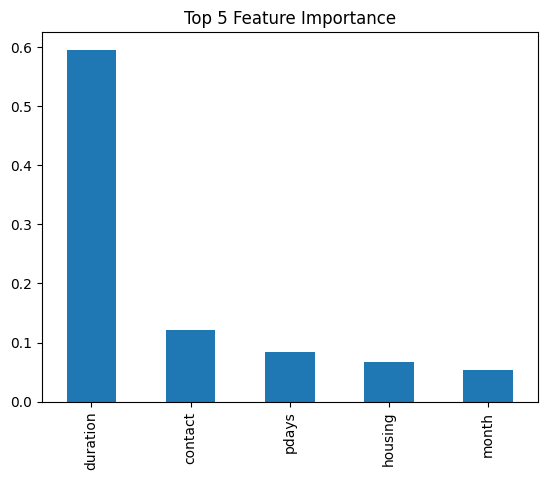

In [22]:
import matplotlib.pyplot as plt

importance = pd.Series(dt.feature_importances_,
                       index=x.columns).sort_values(ascending=False)

importance.head(5).plot(kind='bar')
plt.title('Top 5 Feature Importance')
plt.show()

Interpretation

The most influential feature is:

Duration

Meaning the length of customer interaction strongly affects deposit subscription decisions.

Business Insights
Which Customers Are More Likely to Say "Yes"?

Based on feature importance:

Customers with longer call duration
Customers contacted through effective channels
Customers with previous successful interactions
Customers contacted in favorable months
Customers without housing loan burden
Recommended Bank Strategy
Increase quality and duration of customer conversations.
Focus on customers with positive previous campaign responses.
Use the most effective contact channels.
Target customers during high-conversion months.
Personalize offers based on customer history.

Conclusion

The Decision Tree model achieved 80.52% accuracy and showed that duration, contact type, previous interaction history, housing loan status, and month are the key factors influencing whether a customer subscribes to a term deposit. This insight can help banks optimize marketing campaigns and improve conversion rates.